In [92]:
def set_size(width_pt, fraction=1, subplots=(1, 1)):
    """Set figure dimensions to sit nicely in our document.

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)

# Scaling

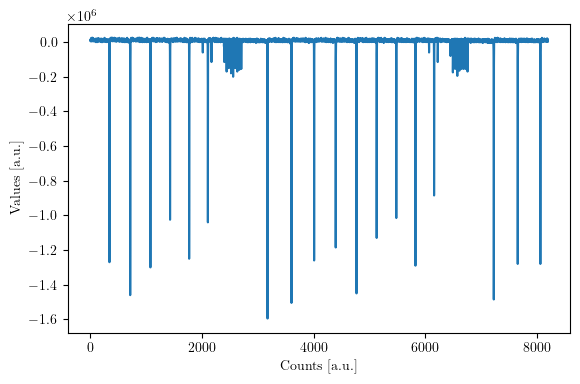

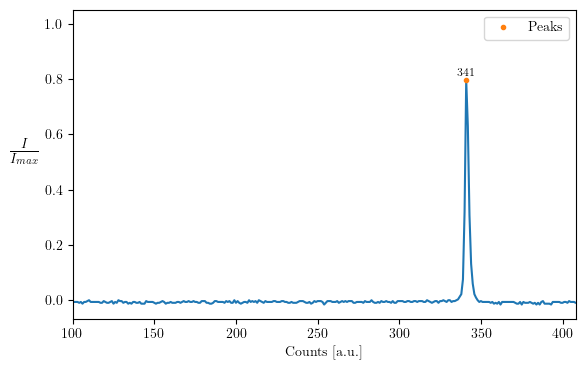

Average distance between peaks: 197.94871794871796
GHz per index: 0.00505181347150259


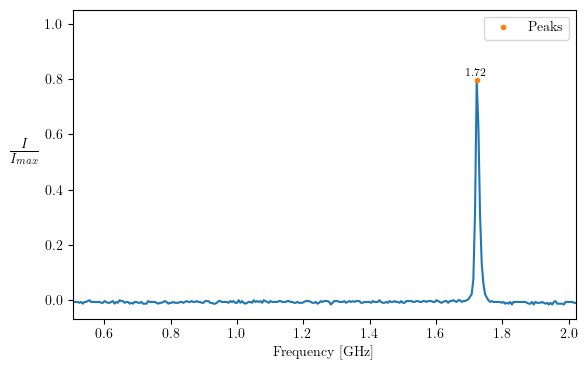

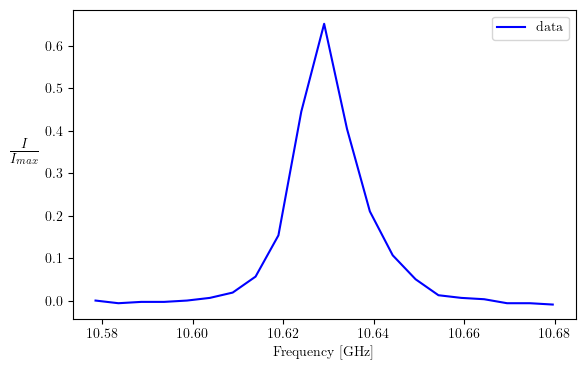

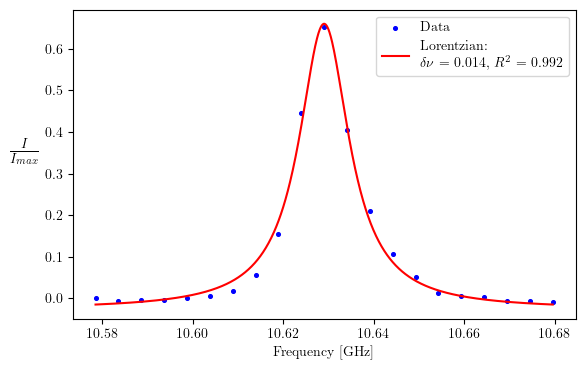

R^2= 0.9920240205980421
dv 0.01352545551144991
Finesse 73.93466335780371


In [93]:
#plot csv file
#import matplotlib as mpl
# Use the pgf backend (must be set before pyplot imported)
#mpl.use('pgf')
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

plt.rcParams.update({
    "font.family": "serif",  # use serif/main font for text elements
    "text.usetex": True,     # use inline math for ticks
    "pgf.rcfonts": False     # don't setup fonts from rc parameters
    })
plt.rcParams['font.size'] = 10


# Load the CSV file
data = pd.read_csv(r'102 mA 20,1 deg 1ms resolution with unblock.csv')

# Clean the column names by removing commas
data.columns = [col.replace(',', '') for col in data.columns]

# Convert the data to numeric values (removing commas in data)
data = data.replace({',': ''}, regex=True).apply(pd.to_numeric)

# Select the series with column name '20000'

series_data = data.iloc[:, 1]
limit = 600


# Plot the original series
plt.figure(figsize=set_size(469))
plt.plot(series_data)
plt.xlabel('Counts [a.u.]')
plt.ylabel('Values [a.u.]')
#plt.savefig(r'Latex\Figures\1\FPI_Data.pgf', format='pgf')
plt.show()

# Flip the data about the x-axis
flipped_series_data = -series_data

# Normalize the flipped data
normalized_flipped_series_data = (flipped_series_data) / (flipped_series_data.max())

# Find peaks in the flipped normalized series
peaks, _ = find_peaks(normalized_flipped_series_data, height = 0.03)

# Calculate distances between consecutive peaks
peak_distances = np.diff(peaks)

# Plot the flipped normalized series with peaks highlighted
fig, ax = plt.subplots(figsize=set_size(469))
ax.plot(normalized_flipped_series_data)
ax.plot(peaks, normalized_flipped_series_data[peaks], '.', label='Peaks')
ax.set_xlabel('Counts [a.u.]')
ax.set_ylabel(r'$\frac{I}{I_{max}}$', rotation='horizontal', labelpad=15, fontsize=14)


# Annotate the peaks
for peak in peaks:
    ax.annotate(peak, (peak, normalized_flipped_series_data[peak]), textcoords="offset points", xytext=(0,3), ha='center', fontsize=8, rotation=0)

ax.legend()
ax.set_xlim(100, 408)
#plt.savefig(r'Latex\Figures\1\FPI_Peaks.pgf', format='pgf')
plt.show()

# Compute the average distance between peaks in the filtered array
average_peak_distance = np.mean(peak_distances)
GHz_per_index = 1/ average_peak_distance
print(f'Average distance between peaks: {average_peak_distance}')
print(f'GHz per index: {GHz_per_index}')

# Compute the x-values in GHz
x_values_GHz = np.arange(len(normalized_flipped_series_data)) * GHz_per_index

# Plot the flipped normalized series with peaks highlighted
fig, ax = plt.subplots(figsize=set_size(469))
ax.plot(x_values_GHz, normalized_flipped_series_data)
ax.plot(peaks * GHz_per_index, normalized_flipped_series_data[peaks], '.', label='Peaks')
ax.set_xlabel('Frequency [GHz]')
ax.set_ylabel(r'$\frac{I}{I_{max}}$', rotation='horizontal', labelpad=15, fontsize=14)


# Annotate the peaks
for peak in peaks:
    ax.annotate(f'{peak * GHz_per_index:.2f}', (peak * GHz_per_index, normalized_flipped_series_data[peak]), textcoords="offset points", xytext=(0,3), ha='center', fontsize=8, rotation=0)

ax.legend()
ax.set_xlim(100 * GHz_per_index, 400 * GHz_per_index)
#plt.savefig(r'Latex\Figures\1\FPI_Peaks_GHz.pgf', format='pgf')
plt.show()


# Define the Lorentzian function with an amplitude parameter
def lorentzian(x, x0, dv, C, y0):
    return  y0 + (2*C/np.pi)*(dv / (4*(x - x0)**2 + (dv)**2))

peak_index = peaks[6]
window_size = 10 # Adjust as needed
window_indices = range(max(0, peak_index - window_size), min(len(normalized_flipped_series_data), peak_index + window_size + 1))
window_x = x_values_GHz[window_indices]
window_y = normalized_flipped_series_data[window_indices]

# Initial parameter estimates
x0_initial = x_values_GHz[peak_index]  # center frequency of the peak
gamma_initial = 0.1  # width of the peak
C_initial = max(window_y)  # height of the peak
y0_initial = normalized_flipped_series_data.min()  # offset

# Now you can use A_initial in your initial parameter estimates
p0 = [x0_initial, gamma_initial, C_initial, y0_initial]

fit_options = {'maxfev': 10000}

# Fit the Lorentzian function to the data in the window
popt, _ = curve_fit(lorentzian, window_x, window_y, p0=p0)

# Calculate the R^2 score for the original fit
predicted_y = lorentzian(window_x, *popt)
r2 = r2_score(window_y, predicted_y)


# Plot the original data and the fitted function for the window only
fig, ax = plt.subplots(figsize=set_size(469))
ax.plot(window_x, window_y, 'b-', label='data')
#ax.plot(window_x, predicted_y, 'r-', label=r'fit: $\delta \nu$=%5.6f, $R^2$=%5.3f' % (popt[1], r2))
ax.set_xlabel('Frequency [GHz]')
ax.set_ylabel(r'$\frac{I}{I_{max}}$', rotation='horizontal', labelpad=15, fontsize=14)
ax.legend()
plt.show()

# Generate high-resolution x-values
high_res_x = np.linspace(window_x.min(), window_x.max(), 1000)

# Calculate the corresponding y-values using the fitted parameters
high_res_y = lorentzian(high_res_x, *popt)

# Plot the original data and the high-resolution fitted function
fig, ax = plt.subplots(figsize=set_size(469))
ax.scatter(window_x, window_y, c='b', label='Data', s=7)
ax.plot(high_res_x, high_res_y, 'r-', label=r'Lorentzian:' + '\n' + r'$\delta \nu$' + f' = {popt[1]:.3f}, ' + r'$R^2$' + f' = {r2:.3f}')
ax.set_xlabel('Frequency [GHz]')
ax.set_ylabel(r'$\frac{I}{I_{max}}$', rotation='horizontal', labelpad=15, fontsize=14)

# Get handles and labels for legend
handles, labels = ax.get_legend_handles_labels()

# Create the legend
legend = ax.legend(handles, labels, loc='best', fancybox=True)

#plt.savefig(r'Latex\Figures\1\FPI_Fit.pgf', format='pgf')
plt.show()

print('R^2=', r2)
print('dv', popt[1])
print('Finesse', 1/popt[1])

# Absorption spectra


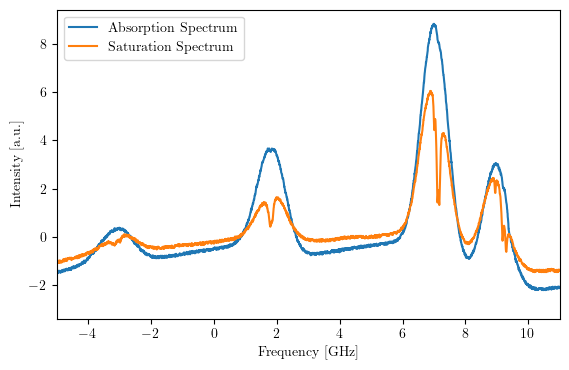

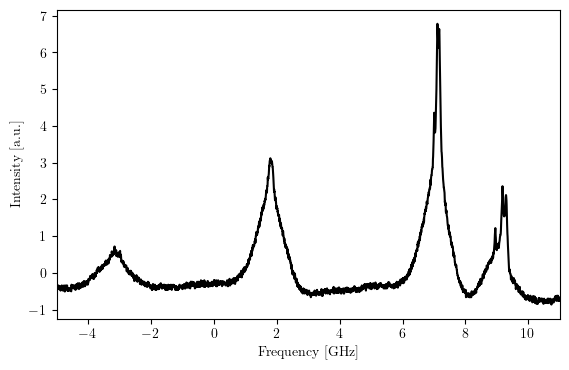

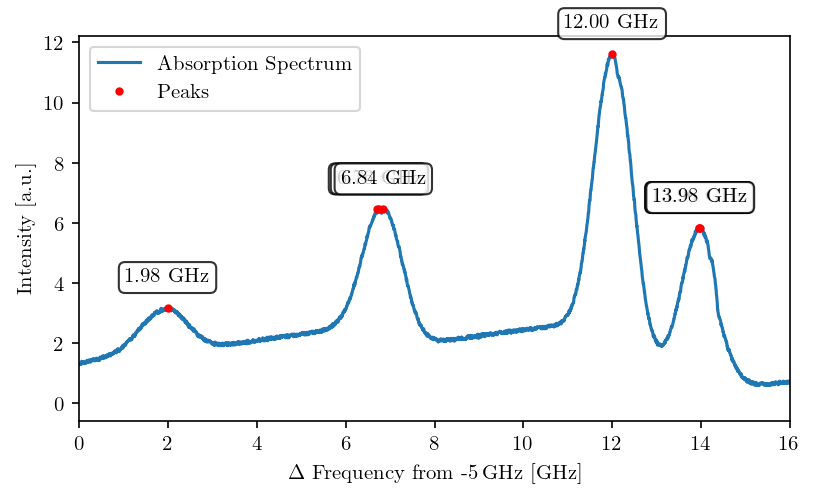

In [94]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
from matplotlib.patches import FancyArrowPatch

# Make sure GHz_per_index is defined (e.g., from your previous cell)
# GHz_per_index = 1 / average_peak_distance

plt.rcParams.update({
    "font.family": "serif",
    "text.usetex": True,
    "pgf.rcfonts": False
})

def find_closest_column(df, target_value):
    best_col, best_diff = None, float("inf")
    for col in df.columns:
        col_clean = str(col).replace(",", "").strip()
        try:
            val = float(col_clean)
            diff = abs(val - target_value)
            if diff < best_diff:
                best_diff, best_col = diff, col
        except ValueError:
            continue
    if best_col is None:
        raise KeyError(f"No numeric column found near {target_value}")
    return best_col

# --- Load & clean ---
data1 = pd.read_csv(r'102 mA 20,1 deg 1ms resolution with unblock.csv')
data2 = pd.read_csv(r'102 mA 20,1 deg 1ms resolution.csv')
data1 = data1.replace({',': ''}, regex=True).apply(pd.to_numeric, errors='ignore')
data2 = data2.replace({',': ''}, regex=True).apply(pd.to_numeric, errors='ignore')

# --- Pick the right columns dynamically ---
col1 = find_closest_column(data1, -50000)
col2 = find_closest_column(data2, -84000)
s1 = data1[col1].values
s2 = data2[col2].values

# --- Build a zero-centered frequency axis ---
n = len(s2)
zero_idx = n // 2
freq_axis = (np.arange(n) - zero_idx) * GHz_per_index

# --- Turn into pandas Series ---
series1 = pd.Series(s1 / 1e5, index=freq_axis)
series2 = pd.Series(s2 / 1e5, index=freq_axis)

# --- Plot absorption vs. saturation (–5 to +11 GHz) ---
plt.figure(figsize=set_size(469))
plt.plot(series2, label='Absorption Spectrum')
plt.plot(series1, label='Saturation Spectrum')
plt.xlim(-5, 11)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Intensity [a.u.]')
plt.legend()
plt.show()

# --- Plot their difference (–5 to +11 GHz) ---
plt.figure(figsize=set_size(469))
plt.plot(series2 - series1, color='black')
plt.xlim(-5, 11)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Intensity [a.u.]')
plt.show()

# --- Peak‐finding on the full absorption spectrum ---
whole = series2 - series2.min()
peaks, _ = find_peaks(whole, distance=2, prominence=1)


# --- Plot all peaks with shifted axis so –5→0 (0 to 16 GHz), high-DPI and boxed labels ---
shift = 5.0
new_x = whole.index + shift  # now ranges from –5→0 up to 11→16

fig, ax = plt.subplots(figsize=set_size(400), dpi=150)      # higher DPI
ax.plot(new_x, whole, label='Absorption Spectrum')
ax.plot(new_x[peaks], whole.iloc[peaks], 'r.', label='Peaks')
ax.set_xlim(0, 16)

# Annotate only peaks that were originally between –5 and +11 GHz
for pk in peaks:
    old_freq = whole.index[pk]
    if -5 <= old_freq <= 11:
        x_shifted = old_freq + shift
        ax.annotate(
            f'{x_shifted:.2f} GHz',
            (x_shifted, whole.iloc[pk]),
            xytext=(0, 12),                      # raise text further
            textcoords="offset points",
            ha='center',
            fontsize=10,                         # slightly larger
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
        )

ax.set_xlabel(r'$\Delta$ Frequency from -5\,GHz [GHz]')
ax.set_ylabel('Intensity [a.u.]')
ax.legend()
plt.tight_layout()
plt.show()

# Original X axis

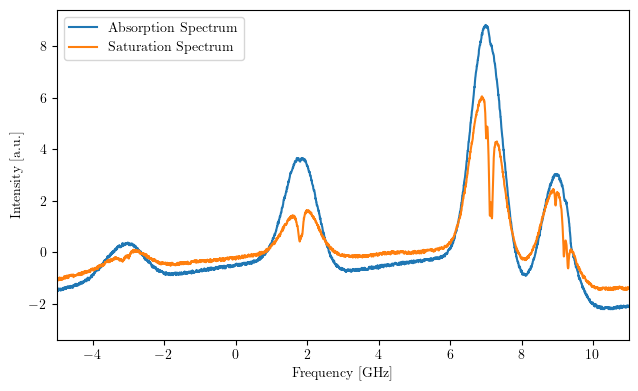

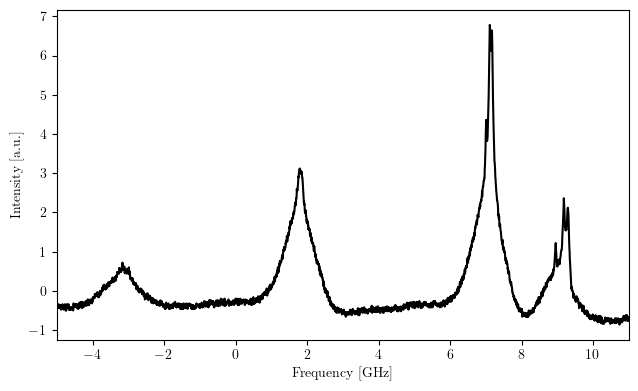

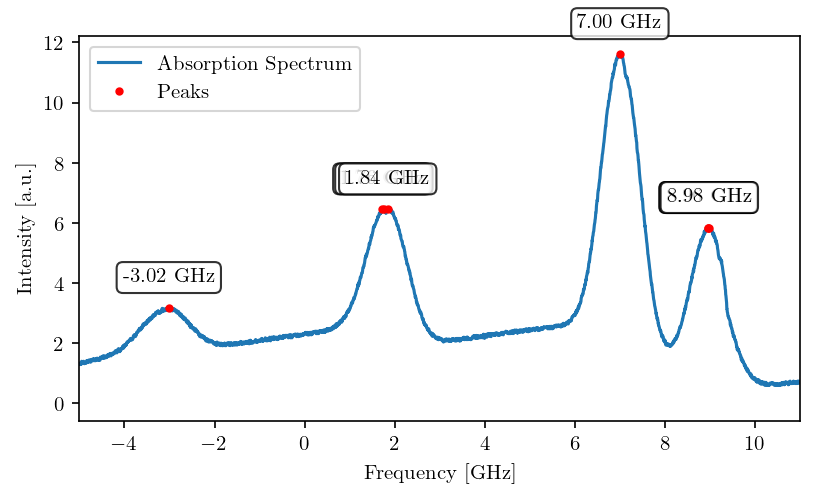

In [95]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
from matplotlib.patches import FancyArrowPatch

# Make sure GHz_per_index is defined (e.g., from your previous cell)
# GHz_per_index = 1 / average_peak_distance

plt.rcParams.update({
    "font.family": "serif",
    "text.usetex": True,
    "pgf.rcfonts": False
})

def find_closest_column(df, target_value):
    best_col, best_diff = None, float("inf")
    for col in df.columns:
        col_clean = str(col).replace(",", "").strip()
        try:
            val = float(col_clean)
            diff = abs(val - target_value)
            if diff < best_diff:
                best_diff, best_col = diff, col
        except ValueError:
            continue
    if best_col is None:
        raise KeyError(f"No numeric column found near {target_value}")
    return best_col

# --- Load & clean ---
data1 = pd.read_csv(r'102 mA 20,1 deg 1ms resolution with unblock.csv')
data2 = pd.read_csv(r'102 mA 20,1 deg 1ms resolution.csv')
data1 = data1.replace({',': ''}, regex=True).apply(pd.to_numeric, errors='ignore')
data2 = data2.replace({',': ''}, regex=True).apply(pd.to_numeric, errors='ignore')

# --- Pick the right columns dynamically ---
col1 = find_closest_column(data1, -50000)
col2 = find_closest_column(data2, -84000)
s1 = data1[col1].values
s2 = data2[col2].values

# --- Build a zero-centered frequency axis ---
n = len(s2)
zero_idx = n // 2
freq_axis = (np.arange(n) - zero_idx) * GHz_per_index

# --- Turn into pandas Series ---
series1 = pd.Series(s1 / 1e5, index=freq_axis)
series2 = pd.Series(s2 / 1e5, index=freq_axis)

# --- Plot absorption vs. saturation (–5 to +11 GHz) ---
plt.figure(figsize=set_size(469))
plt.plot(series2, label='Absorption Spectrum')
plt.plot(series1, label='Saturation Spectrum')
plt.xlim(-5, 11)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Intensity [a.u.]')
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot their difference (–5 to +11 GHz) ---
plt.figure(figsize=set_size(469))
plt.plot(series2 - series1, color='black')
plt.xlim(-5, 11)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Intensity [a.u.]')
plt.tight_layout()
plt.show()

# --- Peak‐finding on the full absorption spectrum ---
whole = series2 - series2.min()
peaks, _ = find_peaks(whole, distance=2, prominence=1)

# --- Plot all peaks on the original axis (–5 to +11 GHz) ---
fig, ax = plt.subplots(figsize=set_size(400), dpi=150)
ax.plot(whole.index, whole, label='Absorption Spectrum')
ax.plot(whole.index[peaks], whole.iloc[peaks], 'r.', label='Peaks')
ax.set_xlim(-5, 11)

# Annotate only peaks between –5 and +11 GHz
for pk in peaks:
    freq = whole.index[pk]
    if -5 <= freq <= 11:
        ax.annotate(
            f'{freq:.2f} GHz',
            (freq, whole.iloc[pk]),
            xytext=(0, 12),            # raise text above the point
            textcoords='offset points',
            ha='center',
            fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
        )

ax.set_xlabel('Frequency [GHz]')
ax.set_ylabel('Intensity [a.u.]')
ax.legend()
plt.tight_layout()
plt.show()


# individual peaks with voigt fit for the 4 peaks. 

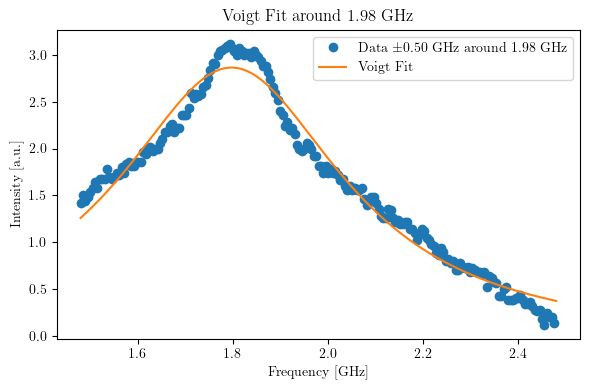

Fitted Voigt parameters:
Amplitude = 2.67 ± 0.104
Center    = 1.7974 GHz ± 0.0023
Sigma     = 0.0000 GHz ± 455694.0088
Gamma     = 0.2891 GHz ± 0.0081
Offset    = -0.0748 ± 0.0492


In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

# --- Your difference spectrum as pandas Series ---
# diff_series = series2 - series1

diff_series = series2 - series1

# --- Force fitting center around exactly 1.98 GHz ---
center_freq = 1.98  # GHz
window = 0.5       # GHz on each side
mask = (diff_series.index >= center_freq - window) & \
       (diff_series.index <= center_freq + window)
x = diff_series.index.values[mask]
y = diff_series.values[mask]

# Expand window if too few points
min_points = 15
while x.size < min_points and window < 1.5:
    window += 0.25
    mask = (diff_series.index >= center_freq - window) & \
           (diff_series.index <= center_freq + window)
    x = diff_series.index.values[mask]
    y = diff_series.values[mask]
if x.size < min_points:
    raise RuntimeError(f"Not enough data ({x.size}) in ±{window:.2f} GHz around {center_freq} GHz.")

# --- Define Voigt profile ---
def voigt_func(x, amplitude, cen, sigma, gamma, offset):
    return amplitude * voigt_profile(x - cen, sigma, gamma) + offset

# --- Initial guesses and bounds ---
amplitude_guess = np.ptp(y)
offset_guess = np.median(y)
sigma_guess = gamma_guess = window / 5
p0 = [amplitude_guess, center_freq, sigma_guess, gamma_guess, offset_guess]
bounds = (
    [0, center_freq - window, 0, 0, offset_guess - amplitude_guess],
    [amplitude_guess * 2, center_freq + window, window, window, offset_guess + amplitude_guess]
)

# --- Perform fit ---
popt, pcov = curve_fit(
    voigt_func, x, y, p0=p0, bounds=bounds, maxfev=10000
)

# Extract results
amplitude, fitted_center, sigma, gamma, offset = popt
perr = np.sqrt(np.diag(pcov))

# --- Smooth fitted curve ---
fit_x = np.linspace(center_freq - window, center_freq + window, 400)
fit_y = voigt_func(fit_x, *popt)

# --- Plot data and fit ---
plt.figure(figsize=(6, 4))
plt.plot(x, y, 'o', label=f'Data ±{window:.2f} GHz around {center_freq:.2f} GHz')
plt.plot(fit_x, fit_y, '-', label='Voigt Fit')
plt.xlabel('Frequency [GHz]')
plt.ylabel('Intensity [a.u.]')
plt.title(f'Voigt Fit around {center_freq:.2f} GHz')
plt.legend()
plt.tight_layout()
plt.show()

# --- Print fitted parameters ---
print("Fitted Voigt parameters:")
print(f"Amplitude = {amplitude:.3g} ± {perr[0]:.3g}")
print(f"Center    = {fitted_center:.4f} GHz ± {perr[1]:.4f}")
print(f"Sigma     = {sigma:.4f} GHz ± {perr[2]:.4f}")
print(f"Gamma     = {gamma:.4f} GHz ± {perr[3]:.4f}")
print(f"Offset    = {offset:.3g} ± {perr[4]:.3g}")


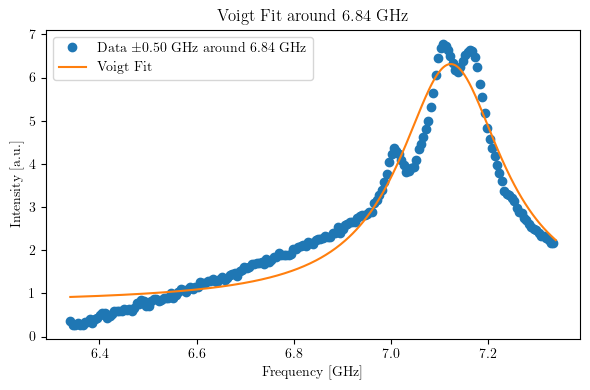

Amplitude  = 2.258 ± 0.07958 
Center [GHz] = 7.124 ± 0.00219 GHz
Sigma [GHz] = 7.693e-22 ± 6.695e+04 GHz
Gamma [GHz] = 0.1297 ± 0.008038 GHz
Offset     = 0.7714 ± 0.06002 


(array([2.25818716e+00, 7.12371494e+00, 7.69334078e-22, 1.29705229e-01,
        7.71384678e-01]),
 array([7.95847656e-02, 2.19008393e-03, 6.69534580e+04, 8.03839356e-03,
        6.00218825e-02]))

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

def fit_voigt_peak(diff_series, center_freq, initial_window=0.5, min_points=15):
    """
    Extracts a ±window slice around center_freq from diff_series,
    fits a Voigt profile, and plots the data + fit.
    Returns popt, perr.
    """
    # 1) Build mask around center
    window = initial_window
    mask = (diff_series.index >= center_freq - window) & \
           (diff_series.index <= center_freq + window)
    x = diff_series.index.values[mask]
    y = diff_series.values[mask]

    # 2) Expand window if too few points
    while x.size < min_points and window < 1.5:
        window += 0.25
        mask = (diff_series.index >= center_freq - window) & \
               (diff_series.index <= center_freq + window)
        x = diff_series.index.values[mask]
        y = diff_series.values[mask]
    if x.size < min_points:
        raise RuntimeError(f"Not enough data ({x.size}) in ±{window:.2f} GHz around {center_freq} GHz.")

    # 3) Voigt model
    def voigt_func(x, amplitude, cen, sigma, gamma, offset):
        return amplitude * voigt_profile(x - cen, sigma, gamma) + offset

    # 4) Initial guesses & bounds
    amplitude_guess = np.ptp(y)
    offset_guess = np.median(y)
    sigma_guess = gamma_guess = window / 5
    p0 = [amplitude_guess, center_freq, sigma_guess, gamma_guess, offset_guess]
    bounds = (
        [0, center_freq - window, 0, 0, offset_guess - amplitude_guess],
        [amplitude_guess * 2, center_freq + window, window, window, offset_guess + amplitude_guess]
    )

    # 5) Fit
    popt, pcov = curve_fit(voigt_func, x, y, p0=p0, bounds=bounds, maxfev=10000)
    perr = np.sqrt(np.diag(pcov))

    # 6) Generate smooth fit curve
    fit_x = np.linspace(center_freq - window, center_freq + window, 400)
    fit_y = voigt_func(fit_x, *popt)

    # 7) Plot
    plt.figure(figsize=(6, 4))
    plt.plot(x, y, 'o', label=f'Data ±{window:.2f} GHz around {center_freq:.2f} GHz')
    plt.plot(fit_x, fit_y, '-', label='Voigt Fit')
    plt.xlabel('Frequency [GHz]')
    plt.ylabel('Intensity [a.u.]')
    plt.title(f'Voigt Fit around {center_freq:.2f} GHz')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 8) Print results
    names = ["Amplitude", "Center [GHz]", "Sigma [GHz]", "Gamma [GHz]", "Offset"]
    for n, val, err in zip(names, popt, perr):
        unit = "GHz" if "GHz" in n else ""
        print(f"{n:10s} = {val:.4g} ± {err:.4g} {unit}")

    return popt, perr

# --- Usage for your 6.84 GHz peak ---
# Assuming series2 and series1 are already defined pandas.Series
diff_series = series2 - series1
fit_voigt_peak(diff_series, center_freq=6.84, initial_window=0.5)


12.00 GHz peak fit:
  A     = 0.5263 ± 0.0231
  f₀    = 12.30631 ± 0.00066 GHz
  σ     = 0.0010 ± 0.0320 GHz
  γ     = 0.0293 ± 0.0028 GHz
  C     = -0.6526 ± 0.0401


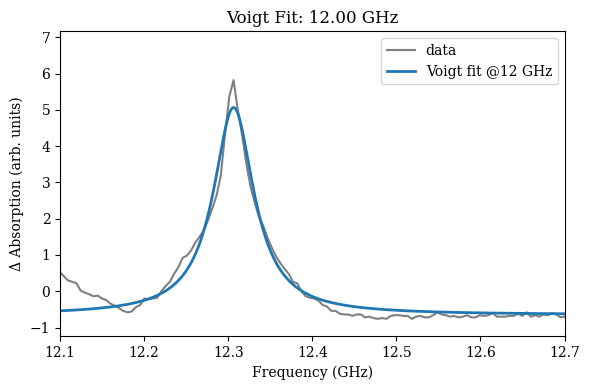

In [88]:
# ===== Voigt fit for 12.00 GHz peak =====
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

# Disable LaTeX in labels
plt.rcParams['text.usetex'] = False

# Your data: either freq & absorb, or diff_series if you want delta absorption
x = diff_series.index.values  # freq axis in GHz
y = diff_series.values        # absorption

# Voigt + offset model
def voigt_plus_offset(f, A, f0, sigma, gamma, C):
    return A * voigt_profile(f - f0, sigma, gamma) + C

# Peak window
center = 12.4
window = 0.3
mask = (x >= center - window) & (x <= center + window)
xw, yw = x[mask], y[mask]

# Initial guesses
A0     = yw.max() - yw.min()
f0_0   = center
sigma0 = 0.05
gamma0 = 0.05
C0     = yw.min()

p0 = [A0, f0_0, sigma0, gamma0, C0]

# Bounds: A>0, sigma/gamma>0, f0 within ±0.2 GHz, C free
lower = [0, center - 0.2,  0.001, 0.001, -np.inf]
upper = [np.inf, center + 0.2, 1.0,   1.0,   np.inf]

popt, pcov = curve_fit(voigt_plus_offset, xw, yw, p0=p0, bounds=(lower, upper))
perr = np.sqrt(np.diag(pcov))

# Unpack & print
A_fit, f0_fit, s_fit, g_fit, C_fit = popt
errA, errf0, errs, errg, errC = perr

print("12.00 GHz peak fit:")
print(f"  A     = {A_fit:.4f} ± {errA:.4f}")
print(f"  f₀    = {f0_fit:.5f} ± {errf0:.5f} GHz")
print(f"  σ     = {s_fit:.4f} ± {errs:.4f} GHz")
print(f"  γ     = {g_fit:.4f} ± {errg:.4f} GHz")
print(f"  C     = {C_fit:.4f} ± {errC:.4f}")

# Plot
fine_x = np.linspace(center - window, center + window, 500)
plt.figure(figsize=(6,4))
plt.plot(x, y,   color='gray', label='data')
plt.plot(fine_x, voigt_plus_offset(fine_x, *popt),
         lw=2, label='Voigt fit @12 GHz')
plt.xlim(center - window, center + window)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Δ Absorption (arb. units)')
plt.title('Voigt Fit: 12.00 GHz')
plt.legend()
plt.tight_layout()
plt.show()


13.98 GHz peak fit:
  A     = 1.5906 ± 0.2713
  f₀    = 9.17220 ± 0.00565 GHz
  σ     = 0.0010 ± 3.5246 GHz
  γ     = 0.2189 ± 0.0547 GHz
  C     = -0.5787 ± 0.1113


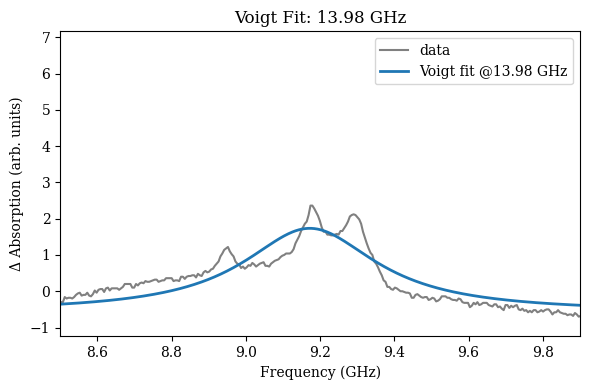

In [89]:
# ===== Voigt fit for 13.98 GHz peak =====
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

plt.rcParams['text.usetex'] = False

x = diff_series.index.values
y = diff_series.values

def voigt_plus_offset(f, A, f0, sigma, gamma, C):
    return A * voigt_profile(f - f0, sigma, gamma) + C

center = 9.2
window = 0.7
mask = (x >= center - window) & (x <= center + window)
xw, yw = x[mask], y[mask]

p0 = [yw.max() - yw.min(), center, 0.05, 0.05, yw.min()]
lower = [0, center - 0.2,  0.001, 0.001, -np.inf]
upper = [np.inf, center + 0.2, 1.0,   1.0,   np.inf]

popt, pcov = curve_fit(voigt_plus_offset, xw, yw, p0=p0, bounds=(lower, upper))
perr = np.sqrt(np.diag(pcov))

A_fit, f0_fit, s_fit, g_fit, C_fit = popt
errA, errf0, errs, errg, errC = perr

print("13.98 GHz peak fit:")
print(f"  A     = {A_fit:.4f} ± {errA:.4f}")
print(f"  f₀    = {f0_fit:.5f} ± {errf0:.5f} GHz")
print(f"  σ     = {s_fit:.4f} ± {errs:.4f} GHz")
print(f"  γ     = {g_fit:.4f} ± {errg:.4f} GHz")
print(f"  C     = {C_fit:.4f} ± {errC:.4f}")

fine_x = np.linspace(center - window, center + window, 500)
plt.figure(figsize=(6,4))
plt.plot(x, y,   color='gray', label='data')
plt.plot(fine_x, voigt_plus_offset(fine_x, *popt),
         lw=2, label='Voigt fit @13.98 GHz')
plt.xlim(center - window, center + window)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Δ Absorption (arb. units)')
plt.title('Voigt Fit: 13.98 GHz')
plt.legend()
plt.tight_layout()
plt.show()


done until here


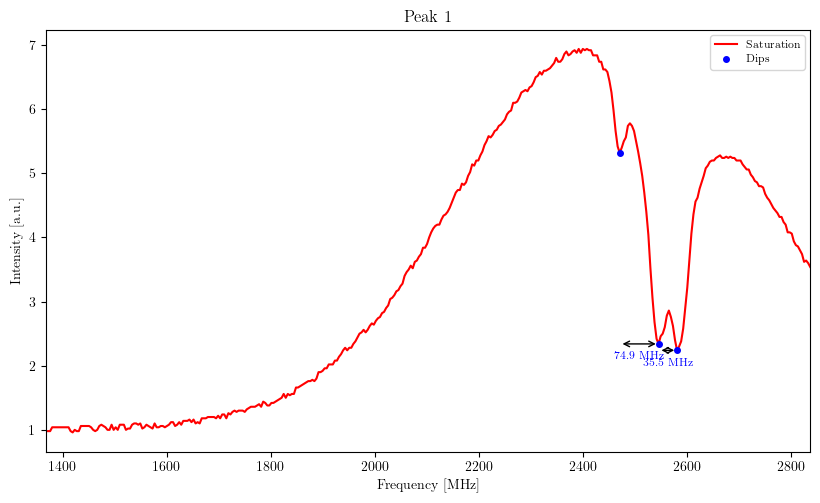

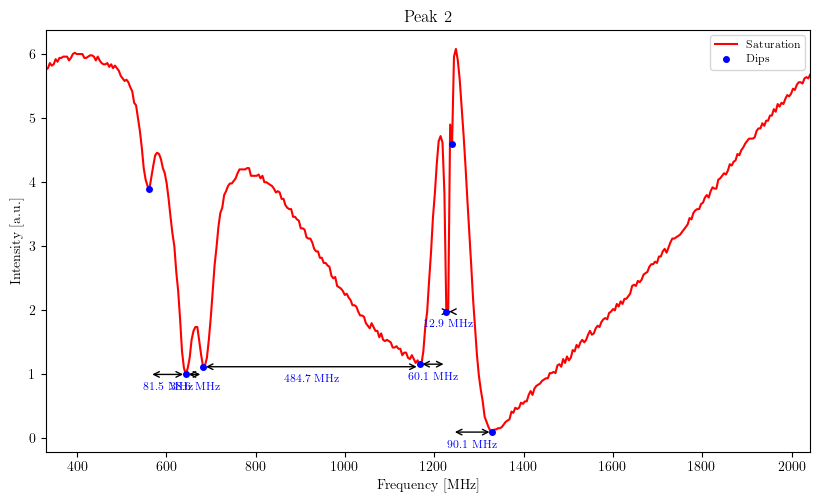

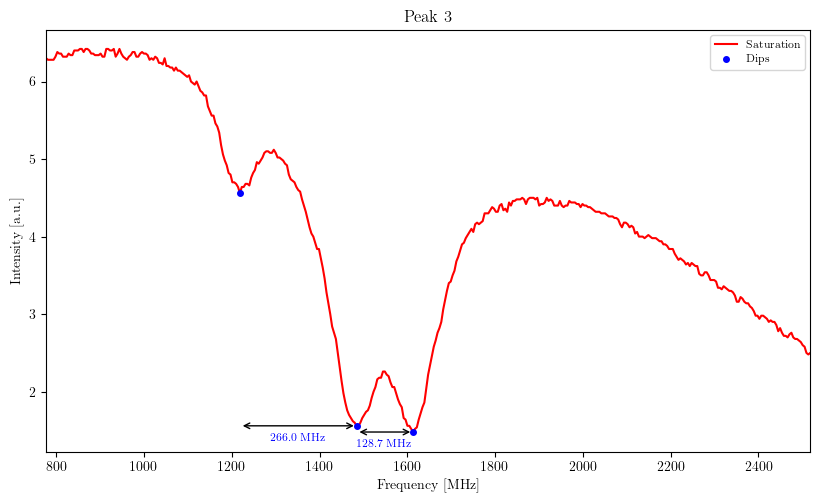

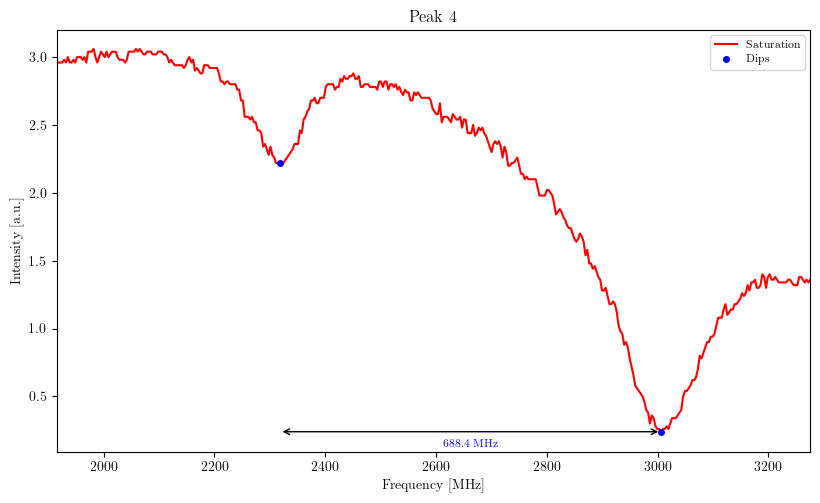

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from matplotlib.patches import FancyArrowPatch

# your per-peak window sizes (lower, upper) in sample-points
window_sizes = {
    1: (260, 114),
    2: (-15, 385),
    3: (-18, 389),
    4: (-20, 390),
}

# your per-peak calibration in GHz/index
GHz_per_index = [
    0.003941372090158887,
    0.004289679535705274,
    0.004289679535705274,
    0.0033255327010715606,
]

def set_size(width_pt, fraction=1):
    inches_per_pt = 1/72.27
    golden_ratio = (np.sqrt(5) - 1)/2
    w = width_pt * fraction * inches_per_pt
    return (w, w*golden_ratio)

for i in range(1,5):
    # 1) load & clean
    df = pd.read_csv(f'Peak {i}.csv')
    df.columns = [c.replace(',', '') for c in df.columns]
    df = df.replace({',':''}, regex=True).apply(pd.to_numeric)
    series = df.iloc[:,0] / 1e5
    series -= series.min()

    # 2) find all peaks, take the first one
    peaks, _ = find_peaks(series, prominence=0.5)
    if peaks.size == 0:
        print(f"no peaks found in file {i}")
        continue
    pk = peaks[0]

    # 3) build window
    lo, hi = window_sizes[i]
    start = max(pk - abs(lo), 0)
    end   = min(pk + abs(hi), len(series))
    if end <= start:
        print(f"invalid window for peak {i}")
        continue

    window_idx = np.arange(start, end)
    window_data = series.iloc[start:end].to_numpy()

    # 4) convert to MHz
    conv = GHz_per_index[i-1] * 1e3
    freqs_MHz = window_idx * conv

    # 5) find dips (inverted peaks) and maxima
    dips, _  = find_peaks(-window_data, prominence=0.11)
    pks, _   = find_peaks(window_data,  prominence=0.13)

    # 6) manual tweaks, if you still need them:
    #    (I recommend you inspect dips/pks arrays here)

    # 7) compute dip distances
    dip_freqs = freqs_MHz[dips]
    dip_distances = np.diff(dip_freqs)

    # 8) plot
    fig, ax = plt.subplots(figsize=set_size(600))
    ax.plot(freqs_MHz, window_data, 'r-', label='Saturation')
    ax.plot(dip_freqs, window_data[dips], 'bo', ms=4, label='Dips')

    # annotate every dip-distance with a double arrow
    for j in range(len(dip_distances)):
        x1, x2 = dip_freqs[j], dip_freqs[j+1]
        y0 = min(window_data[dips[j]], window_data[dips[j+1]])
        arrow = FancyArrowPatch((x1, y0), (x2, y0),
                                arrowstyle='<->', mutation_scale=10)
        ax.add_patch(arrow)
        ax.text((x1+x2)/2, y0 - 0.02*(window_data.max()-window_data.min()),
                f"{dip_distances[j]:.1f} MHz",
                ha='center', va='top', fontsize=8, color='blue')

    ax.set_xlim(freqs_MHz.min(), freqs_MHz.max())
    ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('Intensity [a.u.]')
    ax.set_title(f"Peak {i}")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


# above is the one for you!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

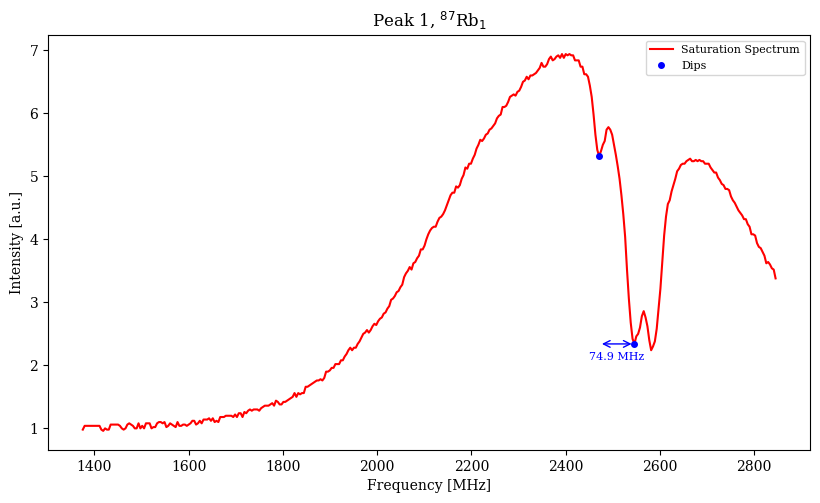

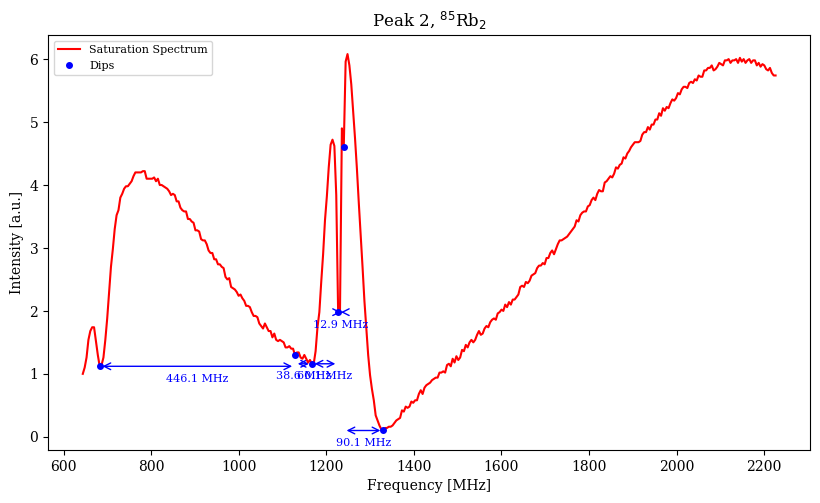

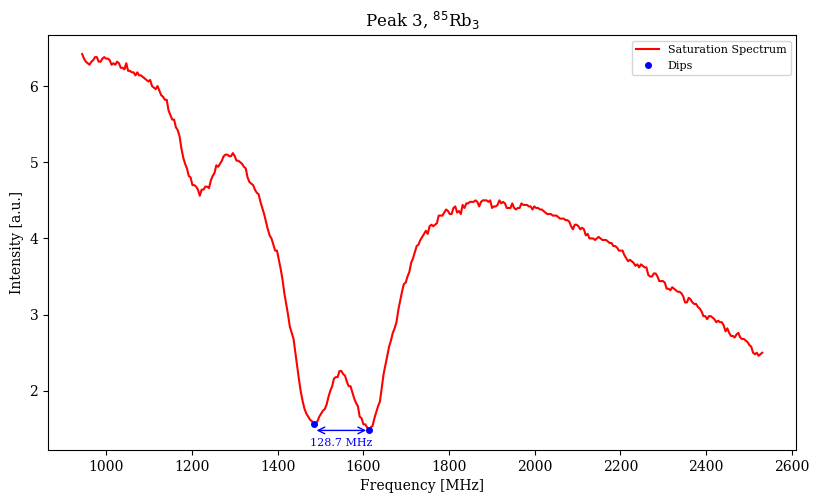

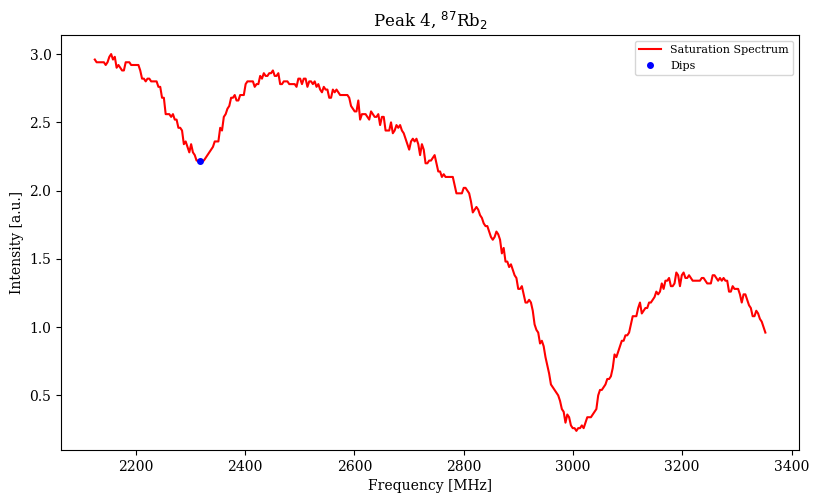

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from scipy.signal import find_peaks

# Define a dictionary with peak numbers as keys and (lower_window_size, upper_window_size) as values
window_sizes = {
    1: (260, 114),
    2: (-15, 385),
    3: (-18, 389),
    4: (-20, 390),
}

GHz_per_index = [0.003941372090158887, 0.004289679535705274, 0.004289679535705274, 0.0033255327010715606]  # Example value, adjust as necessary

# Function to set figure size based on column width
def set_size(width, fraction=1):
    """ Set aesthetic figure dimensions to avoid scaling in LaTeX.

    Parameters:
    - width: Width in pts
    - fraction: Fraction of the width which you wish the figure to occupy

    Returns:
    - fig_dim: Dimensions of figure in inches
    """
    fig_width_pt = width * fraction
    inches_per_pt = 1 / 72.27  # Convert from pt to inches
    golden_ratio = (5**0.5 - 1) / 2  # Aesthetic ratio (you could change this)
    fig_width_in = fig_width_pt * inches_per_pt  # Width of figure in inches
    fig_height_in = fig_width_in * golden_ratio  # Height of figure in inches
    fig_dim = (fig_width_in, fig_height_in)  # Final dimensions of figure in inches
    return fig_dim

# Plotting loop
for i in range(1, 5):
    file_path = f'Peak {i}.csv'
    data = pd.read_csv(file_path)

    # Clean the column names and convert data to numeric values
    data.columns = [col.replace(',', '') for col in data.columns]
    data = data.replace({',': ''}, regex=True).apply(pd.to_numeric)

    # Process the first column of the data
    series_data = data.iloc[:, 0] / 100000
    series_data -= series_data.min()

    # Find peaks
    peaks, _ = find_peaks(series_data, height=0, prominence=0.5)
    if len(peaks) == 0:
        continue

    first_peak = peaks[1]  # Assuming you want to use the second detected peak

    # Retrieve the specific window sizes for the current peak
    lower_window_size, upper_window_size = window_sizes[i]

    # Extract the window of data around the peak
    window_start = max(first_peak - lower_window_size, 0)
    window_end = min(first_peak + upper_window_size, len(series_data))
    window_index = np.arange(window_start, window_end)
    window_data = series_data.iloc[window_start:window_end].to_numpy()

    # Convert window_index to MHz
    window_index_MHz = window_index * GHz_per_index[i-1] * 1000

    # Find dips within the window
    dips, _ = find_peaks(-window_data, prominence=0.11)  # Find minima by inverting the data

    # Find peaks within the window
    peaks_in_window, _ = find_peaks(window_data, prominence=0.13)  # Find maxima

    # Manual adjustments for dips
    if i == 1:
    # Remove the last dip for peak 1
        if len(dips) >= 1:
            dips = dips[:-1]
    elif i == 2:
        # Add a dip at 1.13 GHz for peak 2
        target_freq = 1.13 * 1000
        closest_index = np.argmin(np.abs(window_index_MHz - target_freq))
        dips = np.append(dips, closest_index)
        dips = np.sort(dips)  # Ensure the dips are in sorted order
    elif i == 3:
        # Remove the first dip for peak 3
        if len(dips) > 0:
            dips = dips[1:]

    # Additional manual adjustments for peaks and dips
    if i == 1:
        # Remove the last two peaks for peak 1
        if len(peaks_in_window) >= 2:
            peaks_in_window = peaks_in_window[:-2]
    elif i == 2:
        # Remove the second peak for peak 2
        if len(peaks_in_window) >= 2:
            peaks_in_window = np.delete(peaks_in_window, 1)
    elif i == 3:
        # Remove the last two peaks for peak 3
        if len(peaks_in_window) >= 2:
            peaks_in_window = peaks_in_window[:-2]
    elif i == 4:
        # Remove the last dip for peak 4
        if len(dips) >= 1:
            dips = dips[:-1]

    # Calculate distances between peaks and dips
    peak_distances = np.diff(window_index_MHz[peaks_in_window])
    dip_distances = np.diff(window_index_MHz[dips])

    # Plotting
    plt.figure(figsize=set_size(600))  # Adjust width as necessary

    # Plot with respect to different y-scales
    plt.plot(window_index_MHz, window_data, label='Saturation Spectrum', color='r')
    plt.plot(window_index_MHz[dips], window_data[dips], 'bo', label='Dips', markersize=4)
    #plt.plot(window_index_MHz[peaks_in_window], window_data[peaks_in_window], 'go', label='Peaks', markersize=4)

    # Annotate peak distances
    #for j in range(len(peak_distances)):
        #x1 = window_index_MHz[peaks_in_window[j]]
        #x2 = window_index_MHz[peaks_in_window[j + 1]]
        #y = max(window_data[peaks_in_window[j]], window_data[peaks_in_window[j + 1]])  # Use max value for y-coordinate
        #arrow = FancyArrowPatch((x1, y), (x2, y), arrowstyle='<->', color='green', mutation_scale=12)
        #plt.gca().add_patch(arrow)
        #y_range = window_data.max() - window_data.min()
        #text_y_offset = 0.01 * y_range
        ## Adjust text position to avoid overlap for peaks
        #plt.text((x1 + x2) / 2, y +text_y_offset, f'{peak_distances[j]:.0f} MHz', ha='center', va='bottom', color='green', fontsize=8)

    # Annotate dip distances
    for j in range(len(dip_distances)):
        x1 = window_index_MHz[dips[j]]
        x2 = window_index_MHz[dips[j + 1]]
        y_min = min(window_data[dips[j]], window_data[dips[j + 1]])  # Use min value for y-coordinate
    
        # Calculate dynamic offset based on y-range
        y_range = window_data.max() - window_data.min()
        text_y_offset = -0.02 * y_range  # Adjust this factor as needed
    
        arrow = FancyArrowPatch((x1, y_min), (x2, y_min), arrowstyle='<->', color='blue', mutation_scale=12)
        plt.gca().add_patch(arrow)
    
        # Adjust annotation positions for peak 3
        if i == 3 and j == 1:
            shift = 35  
            x1 += shift
            x2 += shift
        
    
        plt.text((x1 + x2) / 2, y_min + text_y_offset, f'{dip_distances[j]:.1f} MHz', ha='center', va='top', color='blue', fontsize=8)
    plt.xlabel('Frequency [MHz]', fontsize=10)
    plt.ylabel('Intensity [a.u.]', fontsize=10)
    
    if i == 1:
        plt.title(f'Peak {i}, ' + r'$^{87}$Rb$_1$', fontsize=12)
    elif i == 2:
        plt.title(f'Peak {i}, '+ r'$^{85}$Rb$_2$', fontsize=12)
    elif i == 3:
        plt.title(f'Peak {i}, '+ r'$^{85}$Rb$_3$', fontsize=12)
    elif i == 4:
        plt.title(f'Peak {i}, '+ r'$^{87}$Rb$_2$', fontsize=12)

    plt.legend(fontsize=8)
    plt.tight_layout()  # Improve spacing  
    plt.show()


Peak 1: Average distance between peaks: 41.34517766497462, GHz per index: 0.0241866175567833


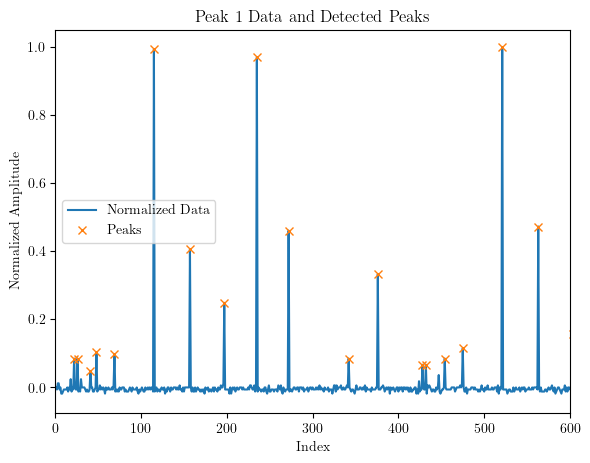

Peak 2: Average distance between peaks: 41.34517766497462, GHz per index: 0.0241866175567833


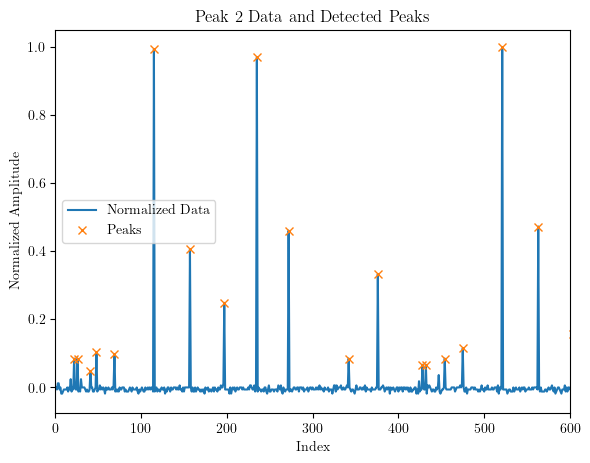

Peak 3: Average distance between peaks: 41.34517766497462, GHz per index: 0.0241866175567833


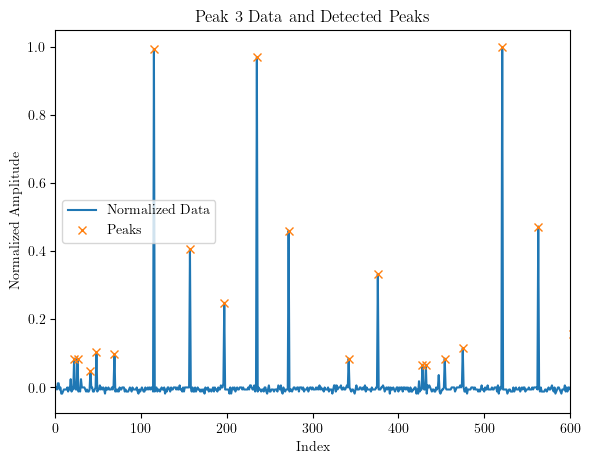

Peak 4: Average distance between peaks: 41.34517766497462, GHz per index: 0.0241866175567833


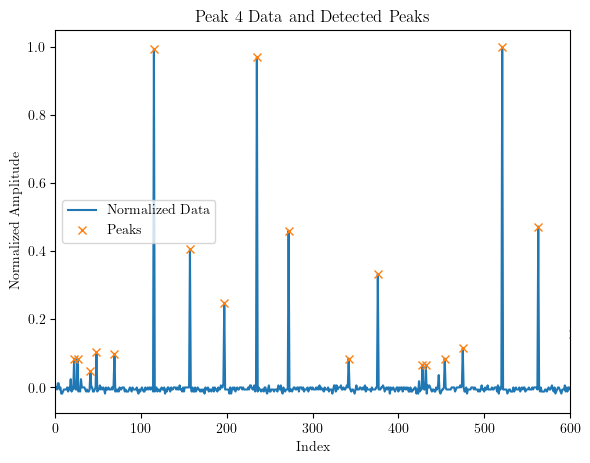

In [32]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

def set_size(width, fraction=1):
    # Assuming the width is in points
    fig_width_pt = width * fraction
    inches_per_pt = 1 / 72.27
    fig_width_in = fig_width_pt * inches_per_pt
    fig_height_in = fig_width_in * (3/4)  # Golden ratio
    return (fig_width_in, fig_height_in)

for i in range(1, 5):
    file_path = f'Task 4\\102mA\\Broad.csv'
    data = pd.read_csv(file_path)

    # Clean and convert data
    data.columns = [col.replace(',', '') for col in data.columns]
    data = data.replace({',': ''}, regex=True).apply(pd.to_numeric)

    series_data = data.iloc[:, 1]
    flipped_series_data = -series_data
    normalized_flipped_series_data = flipped_series_data / flipped_series_data.max()

    peaks, _ = find_peaks(normalized_flipped_series_data, height=0.04, prominence=0)
    peak_distances = np.diff(peaks)

    if len(peak_distances) > 0:
        average_peak_distance = np.mean(peak_distances)
        GHz_per_index = 1 / average_peak_distance
        print(f'Peak {i}: Average distance between peaks: {average_peak_distance}, GHz per index: {GHz_per_index}')
    else:
        print(f'Peak {i}: No peaks found')

    # Plotting
    plt.figure(figsize=set_size(480))
    plt.plot(normalized_flipped_series_data, label='Normalized Data')
    plt.plot(peaks, normalized_flipped_series_data[peaks], "x", label='Peaks')
    plt.title(f'Peak {i} Data and Detected Peaks')
    plt.xlabel('Index')
    plt.ylabel('Normalized Amplitude')
    plt.xlim(0, 600)
    plt.legend()
    plt.show()

Peak 1: Average distance between peaks: 81.3, GHz per index: 0.012300123001230012


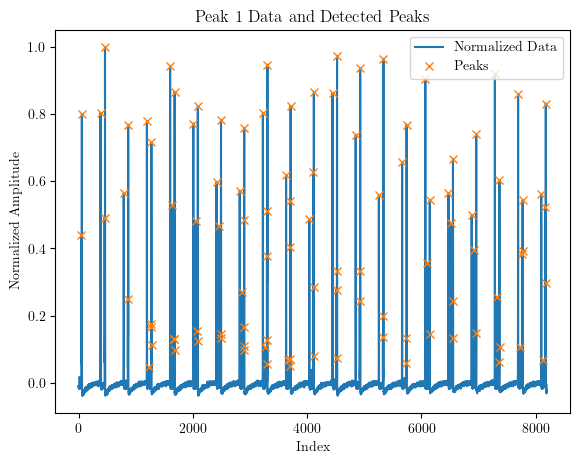

Peak 2: Average distance between peaks: 265.9655172413793, GHz per index: 0.003759885906910411


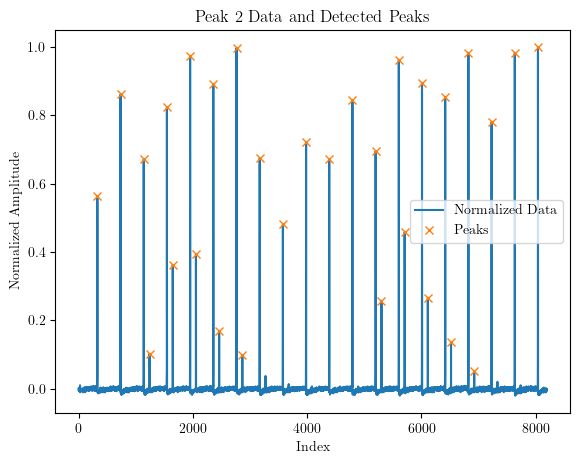

Peak 3: Average distance between peaks: 129.1904761904762, GHz per index: 0.007740508661997787


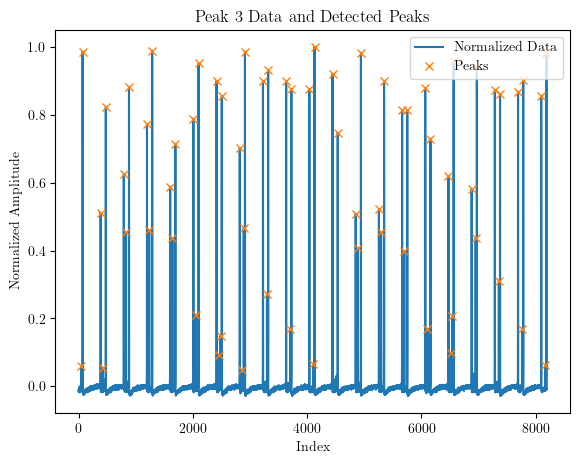

Peak 4: Average distance between peaks: 129.015873015873, GHz per index: 0.007750984251968504


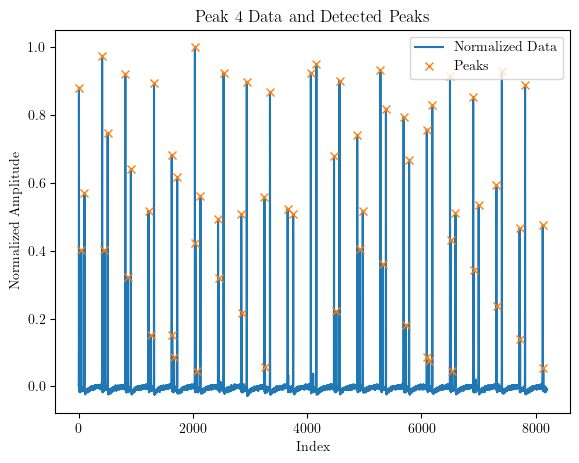

In [33]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

def set_size(width, fraction=1):
    # Assuming the width is in points
    fig_width_pt = width * fraction
    inches_per_pt = 1 / 72.27
    fig_width_in = fig_width_pt * inches_per_pt
    fig_height_in = fig_width_in * (3/4)  # Golden ratio
    return (fig_width_in, fig_height_in)

for i in range(1, 5):
    file_path = f'Task 4\\118mA\\Peak{i}.csv'
    data = pd.read_csv(file_path)

    # Clean and convert data
    data.columns = [col.replace(',', '') for col in data.columns]
    data = data.replace({',': ''}, regex=True).apply(pd.to_numeric)

    series_data = data.iloc[:, 1]
    flipped_series_data = -series_data
    normalized_flipped_series_data = flipped_series_data / flipped_series_data.max()

    peaks, _ = find_peaks(normalized_flipped_series_data, height=0.04, prominence=0)
    peak_distances = np.diff(peaks)

    if len(peak_distances) > 0:
        average_peak_distance = np.mean(peak_distances)
        GHz_per_index = 1 / average_peak_distance
        print(f'Peak {i}: Average distance between peaks: {average_peak_distance}, GHz per index: {GHz_per_index}')
    else:
        print(f'Peak {i}: No peaks found')

    # Plotting
    plt.figure(figsize=set_size(480))
    plt.plot(normalized_flipped_series_data, label='Normalized Data')
    plt.plot(peaks, normalized_flipped_series_data[peaks], "x", label='Peaks')
    plt.title(f'Peak {i} Data and Detected Peaks')
    plt.xlabel('Index')
    plt.ylabel('Normalized Amplitude')
    #plt.xlim(0, 600)
    plt.legend()
    plt.show()